In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

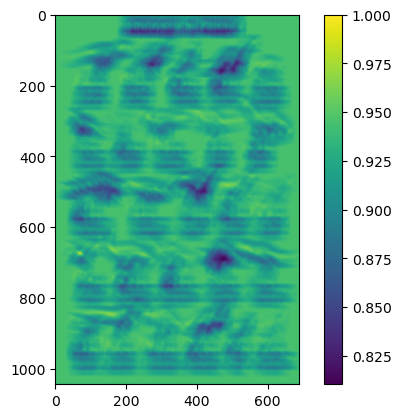

In [6]:
match = cv2.matchTemplate(image, template, cv2.TM_CCORR_NORMED)
plt.imshow(match)#, cmap='hot')
plt.colorbar()
plt.show()

In [7]:
np.where(match == match.max()) # координаты "мэтча"

(array([675]), array([70]))

Можно сравнивать изображения используя признаки объектов вместо информации о цвете пикселей. Для этого нам понадобится нейронная сеть, а точнее та её часть, которая используется (обучена) для извлечения признаков

Схема использования нейросети для извлечения признаков и построения тепловой карты выглядит следующим образом:

<img src="/home/cyberpsychoz/NSU_studying-IIR/2_course/1_sem/PAC/images/Labs/I/get_heatmap.png" alt="heat map" height=30% width=30%>

### Задание: Найти динозавра
1) Выбрать одинаковых динозавров с разных изображений
2) Получить признаки изображения с помощью ResNet. (Использовать output с layer4)
3) Получить признаки одного динозавра с соседнего изображения (использовать output с avgpool)
4) Сравнивая признаки ("косинусное" расстояние) найти динозавра на изображении. Построить тепловую карту

In [21]:
import cv2
import torch
import matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms as T
import torch.nn.functional as F
from PIL import Image

TEMPLATE_PATH = 'image.png'
TARGET_IMG_PATH = 'A_B_C.jpg'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:


template = cv2.cvtColor(cv2.imread(TEMPLATE_PATH), cv2.COLOR_BGR2RGB)
img_target = cv2.cvtColor(cv2.imread(TARGET_IMG_PATH), cv2.COLOR_BGR2RGB)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
model.eval()

features = {}

def get_features(name):
    def hook(module, inputs, output):
        features[name] = output
    return hook

model.layer4.register_forward_hook(get_features('layer4'))
model.avgpool.register_forward_hook(get_features('avgpool'))

In [23]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

template_tensor = transform(Image.fromarray(template)).unsqueeze(0).to(device)
img_target_tensor = transform(Image.fromarray(img_target)).unsqueeze(0).to(device)

with torch.no_grad():
    model(img_target_tensor)
    target_features = features['layer4'].clone() 
    
    model(template_tensor)
    template_embedding = features['avgpool'].clone()


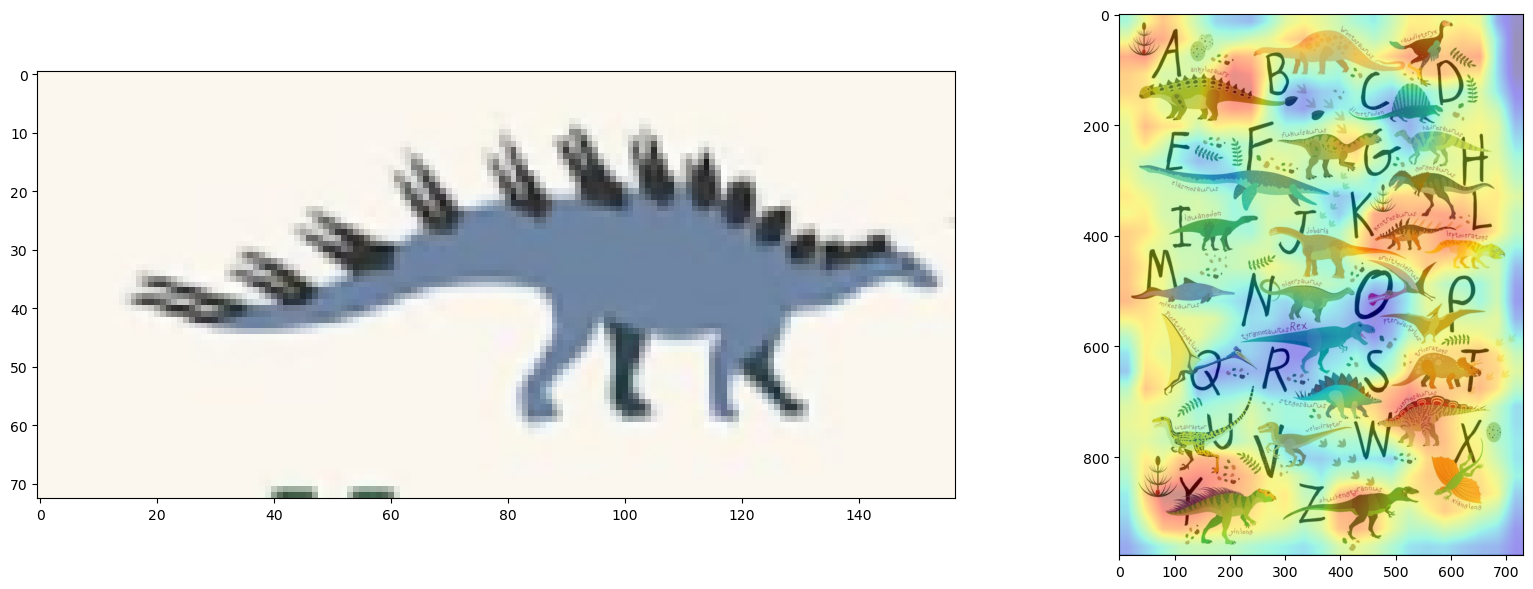

In [24]:

heatmap_tensor = F.cosine_similarity(target_features, template_embedding, dim=1)

heatmap = heatmap_tensor.squeeze().cpu().numpy()

h_target, w_target, _ = img_target.shape
heatmap_resized = cv2.resize(heatmap, (w_target, h_target))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(template)

axes[1].imshow(img_target)
im_hm = axes[1].imshow(heatmap_resized, cmap='jet', alpha=0.4) 

plt.tight_layout()
plt.show()